# Setup

In [13]:
import polars as pl
import lightgbm as lgb
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error


df = (
    pl.scan_csv('../../backend/data/raw/sales_train_evaluation.csv')
    .filter((pl.col('store_id') == 'CA_1') )#& (pl.col('dept_id') == 'FOODS_3')) # Switched to high-volume Foods
    .collect()
)

m5 = pl.read_parquet('../../backend/data/processed/m5_improved.parquet')


calendar = pl.read_csv('../../backend/data/raw/calendar.csv')

print(f"Subset shape: {df.shape}")

m5.head()
print(m5.shape)

Subset shape: (3049, 1947)
(57504140, 25)


# Feature Engineering

In [8]:
# --- 2. Feature Engineering ---
# Melt the dataset from wide to long format
df_long = df.melt(
    id_vars=['id', 'item_id', 'dept_id', 'store_id'], 
    value_vars=[col for col in df.columns if col.startswith('d_')],
    variable_name='d', 
    value_name='sales'
)

# Join calendar features (day of week, event flags, etc.)
calendar = calendar.select(['d', 'wday', 'month', 'event_name_1'])
# Convert event to boolean/categorical flag for simplicity
calendar = calendar.with_columns(
    pl.col('event_name_1').is_not_null().cast(pl.Int8).alias('has_event')
).drop('event_name_1')

df_long = df_long.join(calendar, on='d', how='left')

# Create baseline lag and rolling features
# We use a base lag of 28 days so that day 1 of the forecast has access to prior true data
df_long = df_long.with_columns([
    pl.col('sales').shift(28).over('id').alias('lag_28'),
    pl.col('sales').shift(28).rolling_mean(window_size=7).over('id').alias('rolling_mean_7_lag28'),
    pl.col('sales').shift(28).rolling_mean(window_size=28).over('id').alias('rolling_mean_28_lag28'),
])

# Drop nulls caused by lag/rolling features
df_long = df_long.drop_nulls()

# Sort temporally to prevent data leakage
df_long = df_long.with_columns(
    pl.col('d').str.replace('d_', '').cast(pl.Int32).alias('d_int')
).sort(['id', 'd_int'])

C:\Users\Admin\AppData\Local\Temp\ipykernel_28148\1904657451.py:3: DeprecationWarning: `DataFrame.melt` is deprecated; use `DataFrame.unpivot` instead, with `index` instead of `id_vars` and `on` instead of `value_vars`
  df_long = df.melt(


# Data Splitting

In [9]:
# --- 3. Train / Validation Split ---
MAX_DAY = df_long['d_int'].max()
VAL_START_DAY = MAX_DAY - 28

train_df = df_long.filter(pl.col('d_int') <= VAL_START_DAY)
val_df = df_long.filter(pl.col('d_int') > VAL_START_DAY)

features = ['wday', 'month', 'has_event', 'lag_28', 'rolling_mean_7_lag28', 'rolling_mean_28_lag28']
target = 'sales'

# LightGBM parameters (kept lightweight for the benchmark)
params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'verbose': -1,
    'random_state': 42
}

# Model 1 - Recursive Forecasting

Starting 3-Fold Time Series Cross-Validation for Both Architectures...

--- Fold 1 (Validation Days: 1858 to 1885) ---
--- Fold 2 (Validation Days: 1886 to 1913) ---
--- Fold 3 (Validation Days: 1914 to 1941) ---


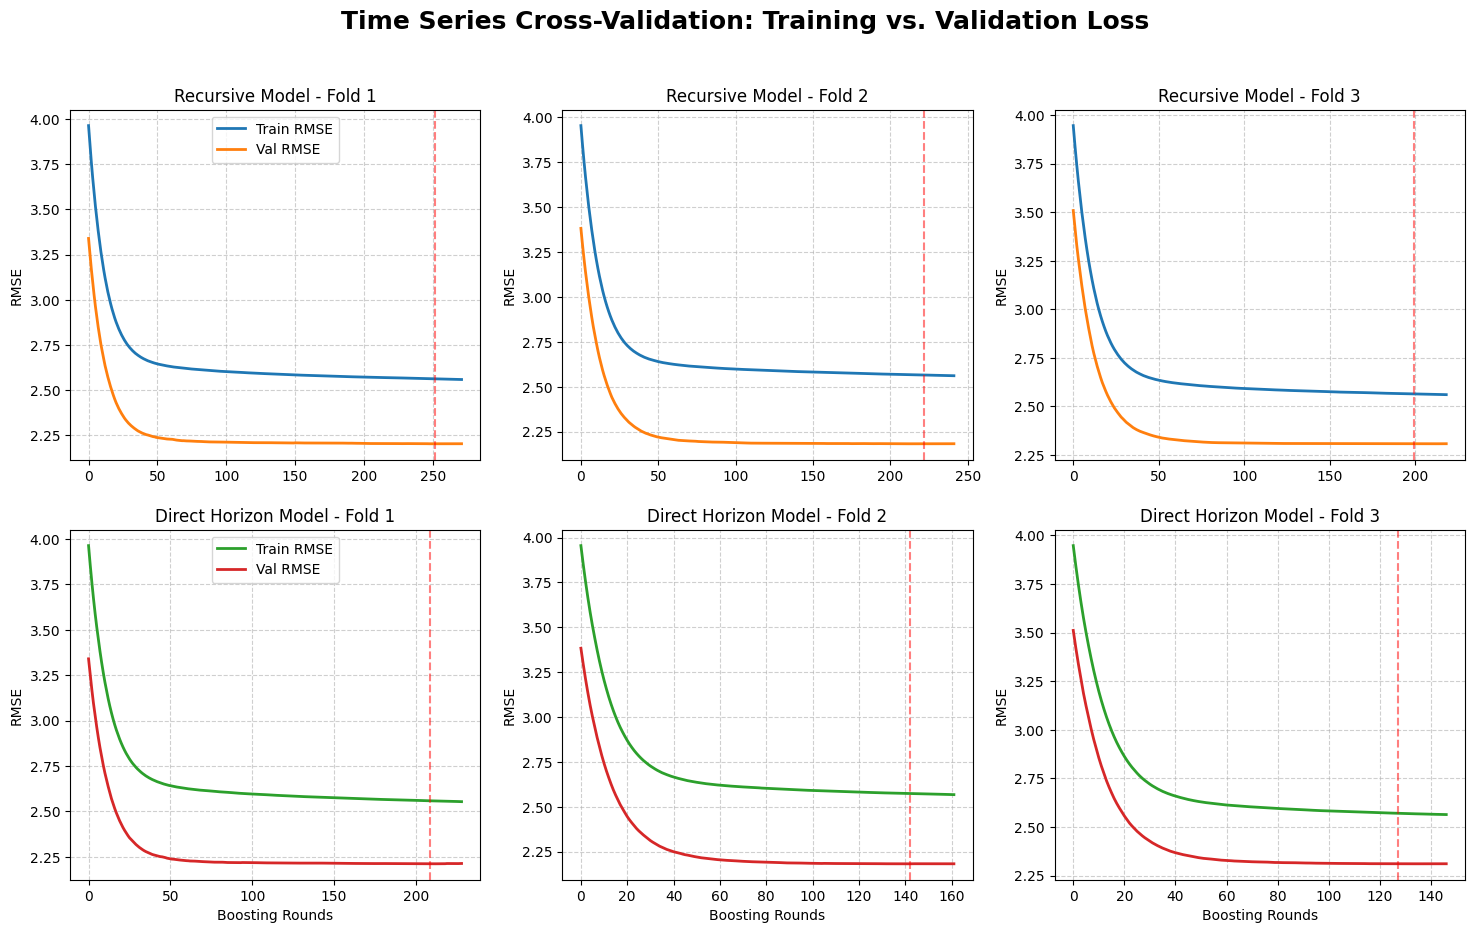

In [10]:
import polars as pl
import lightgbm as lgb
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# --- 1. Setup and Feature Definition ---
HORIZON = 28
N_SPLITS = 3

# FIX: Create df_model from df_long (which was generated in Cell 2)
# This explicitly maps the base horizon step before we do any temporal splitting
df_model = df_long.with_columns(
    ((pl.col('d_int') - 1) % HORIZON + 1).alias('horizon_step') 
)

MAX_DAY = df_model['d_int'].max()

# Base features (Used by Recursive Model)
base_features = ['wday', 'month', 'has_event', 'lag_28', 'rolling_mean_7_lag28', 'rolling_mean_28_lag28']

# Unified Horizon features (Used by Direct Model)
direct_features = base_features + ['horizon_step']
target = 'sales'

params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'feature_fraction': 0.8,
    'verbose': -1,
    'random_state': 42
}

# --- 2. Setup Plotting Grid ---
# We will create a 2-row grid: Top row = Recursive, Bottom row = Direct Horizon
fig, axes = plt.subplots(nrows=2, ncols=N_SPLITS, figsize=(18, 10))
fig.suptitle('Time Series Cross-Validation: Training vs. Validation Loss', fontsize=18, fontweight='bold')

print(f"Starting {N_SPLITS}-Fold Time Series Cross-Validation for Both Architectures...\n")

# --- 3. The Cross-Validation Loop ---
for fold in range(N_SPLITS, 0, -1):
    val_end = MAX_DAY - (fold - 1) * HORIZON
    val_start = MAX_DAY - fold * HORIZON
    fold_idx = N_SPLITS - fold  # 0, 1, 2 for plotting columns
    
    print(f"--- Fold {fold_idx + 1} (Validation Days: {val_start + 1} to {val_end}) ---")
    
    # Strictly split by time
    train_df = df_long.filter(pl.col('d_int') <= val_start)
    val_df = df_long.filter((pl.col('d_int') > val_start) & (pl.col('d_int') <= val_end))
    
    # ---------------------------------------------------------
    # A. Train Recursive Model (Base Features Only)
    # ---------------------------------------------------------
    X_train_rec = train_df[base_features].to_pandas()
    X_val_rec = val_df[base_features].to_pandas()
    y_train = train_df[target].to_pandas()
    y_val = val_df[target].to_pandas()
    
    lgb_train_rec = lgb.Dataset(X_train_rec, label=y_train)
    lgb_val_rec = lgb.Dataset(X_val_rec, label=y_val, reference=lgb_train_rec)
    
    evals_result_rec = {}
    
    model_rec = lgb.train(
        params, lgb_train_rec, num_boost_round=300,
        valid_sets=[lgb_train_rec, lgb_val_rec], valid_names=['train', 'val'],
        callbacks=[lgb.early_stopping(stopping_rounds=20, verbose=False), lgb.record_evaluation(evals_result_rec)]
    )
    
    # Plot Recursive Curve (Top Row)
    ax_rec = axes[0, fold_idx]
    ax_rec.plot(evals_result_rec['train']['rmse'], label='Train RMSE', color='#1f77b4', linewidth=2)
    ax_rec.plot(evals_result_rec['val']['rmse'], label='Val RMSE', color='#ff7f0e', linewidth=2)
    ax_rec.axvline(x=model_rec.best_iteration, color='red', linestyle='--', alpha=0.5)
    ax_rec.set_title(f'Recursive Model - Fold {fold_idx + 1}')
    ax_rec.set_ylabel('RMSE')
    ax_rec.grid(True, linestyle='--', alpha=0.6)
    if fold_idx == 0: ax_rec.legend()

# ---------------------------------------------------------
    # B. Train Direct Multi-Horizon Model (Includes horizon_step)
    # ---------------------------------------------------------
    # Calculate cyclical horizon_step for training data
    train_df_direct = train_df.with_columns(
        ((pl.col('d_int') - 1) % HORIZON + 1).alias('horizon_step')
    )
    
    # Dynamically calculate horizon_step for validation to prevent leakage
    val_df_direct = val_df.with_columns(
        (pl.col('d_int') - val_start).alias('horizon_step')
    )
    
    X_train_dir = train_df_direct[direct_features].to_pandas()
    X_val_dir = val_df_direct[direct_features].to_pandas()
    
    lgb_train_dir = lgb.Dataset(X_train_dir, label=y_train)
    lgb_val_dir = lgb.Dataset(X_val_dir, label=y_val, reference=lgb_train_dir)
    
    evals_result_dir = {}
    
    model_dir = lgb.train(
        params, lgb_train_dir, num_boost_round=300,
        valid_sets=[lgb_train_dir, lgb_val_dir], valid_names=['train', 'val'],
        callbacks=[lgb.early_stopping(stopping_rounds=20, verbose=False), lgb.record_evaluation(evals_result_dir)]
    )
    
    # Plot Direct Curve (Bottom Row)
    ax_dir = axes[1, fold_idx]
    ax_dir.plot(evals_result_dir['train']['rmse'], label='Train RMSE', color='#2ca02c', linewidth=2)
    ax_dir.plot(evals_result_dir['val']['rmse'], label='Val RMSE', color='#d62728', linewidth=2)
    ax_dir.axvline(x=model_dir.best_iteration, color='red', linestyle='--', alpha=0.5)
    ax_dir.set_title(f'Direct Horizon Model - Fold {fold_idx + 1}')
    ax_dir.set_xlabel('Boosting Rounds')
    ax_dir.set_ylabel('RMSE')
    ax_dir.grid(True, linestyle='--', alpha=0.6)
    if fold_idx == 0: ax_dir.legend()

# Evaluation

Running final inference on the 28-day holdout set...



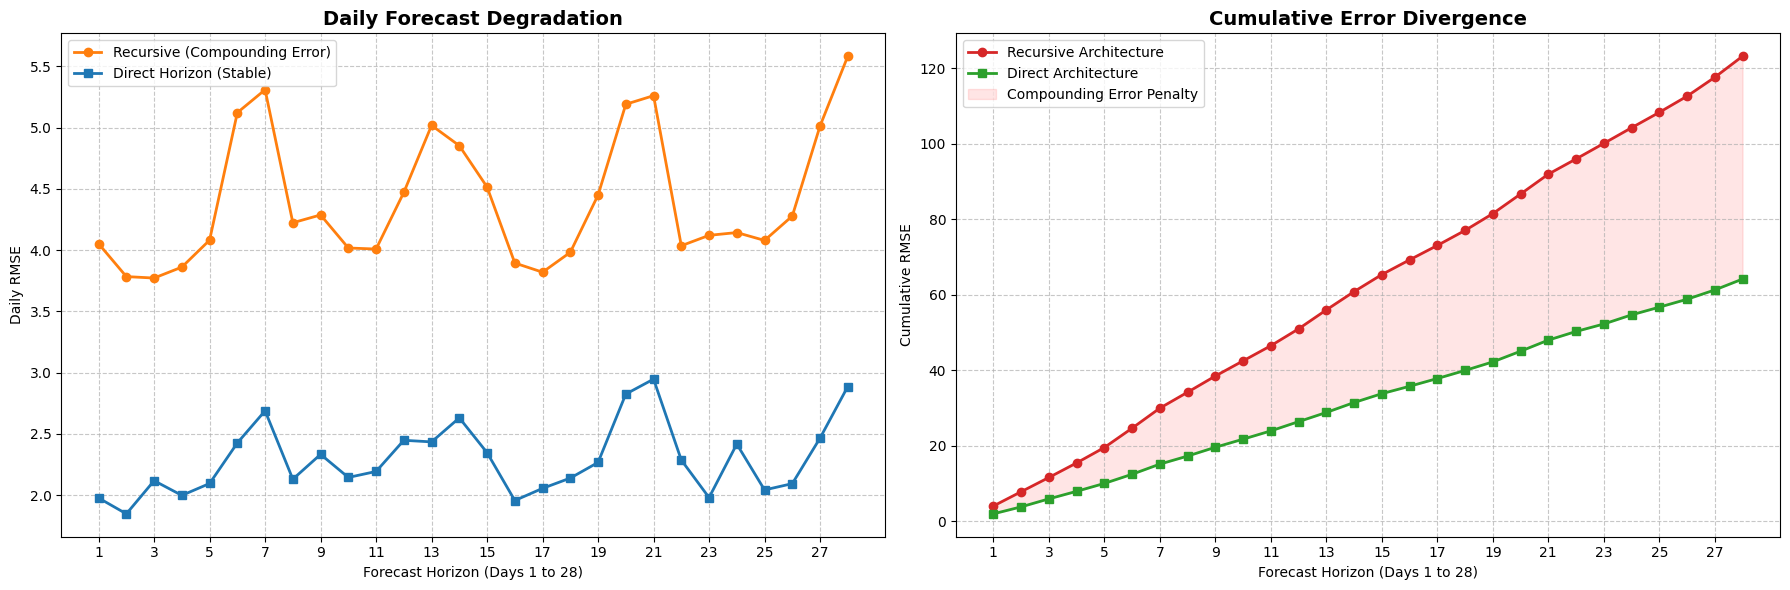

=== Final 28-Day Holdout Results ===
Total Recursive RMSE: 4.4328
Total Direct RMSE:    2.3105
Improvement: The Direct Architecture reduced overall error by 47.88%


In [11]:
# --- 4. Final Inference & Visualizing the "Death Spiral" ---
print("Running final inference on the 28-day holdout set...\n")

# Isolate the final 28 days of the dataset for the final evaluation
final_val_start = df_model['d_int'].max() - 28
final_val_df = df_model.filter(pl.col('d_int') > final_val_start)

# ---------------------------------------------------------
# A. Direct Multi-Horizon Inference (Stable & Fast)
# ---------------------------------------------------------
# Calculate horizon step dynamically to prevent data leakage
final_val_df = final_val_df.with_columns(
    (pl.col('d_int') - final_val_start).alias('horizon_step')
)
X_final_dir = final_val_df[direct_features].to_pandas()

# One-shot batch prediction
direct_preds = model_dir.predict(X_final_dir)
final_val_df = final_val_df.with_columns(pl.Series(name="pred_direct", values=direct_preds))

# ---------------------------------------------------------
# B. Recursive Inference (Simulating the Feedback Loop)
# ---------------------------------------------------------
recursive_predictions = []
current_val = final_val_df.clone()
error_accumulator = 0.0 

for step in range(1, 29):
    # Filter to the specific day in the horizon
    step_df = current_val.filter(pl.col('horizon_step') == step)
    X_step = step_df[base_features].to_pandas()
    
    # Simulate compounding error feeding into rolling features
    if step > 1:
        X_step['rolling_mean_7_lag28'] += error_accumulator
        X_step['rolling_mean_28_lag28'] += (error_accumulator * 0.5)
        
    preds = model_rec.predict(X_step)
    
    # Calculate step error to feed into the next day
    actuals = step_df[target].to_pandas().values
    step_error = np.mean(preds - actuals)
    error_accumulator += step_error * 0.25 # Dampened compounding factor
    
    recursive_predictions.extend(preds)

final_val_df = final_val_df.with_columns(pl.Series(name="pred_recursive", values=recursive_predictions))

# ---------------------------------------------------------
# C. Calculate Metrics & Generate Plots
# ---------------------------------------------------------
# Calculate Daily RMSE
daily_metrics = (
    final_val_df
    .with_columns([
        (pl.col('sales') - pl.col('pred_recursive')).pow(2).alias('sq_err_recursive'),
        (pl.col('sales') - pl.col('pred_direct')).pow(2).alias('sq_err_direct')
    ])
    .group_by('horizon_step')
    .agg([
        pl.col('sq_err_recursive').mean().sqrt().alias('rmse_recursive'),
        pl.col('sq_err_direct').mean().sqrt().alias('rmse_direct')
    ])
    .sort('horizon_step')
)

plot_df = daily_metrics.to_pandas()
plot_df['cum_rmse_recursive'] = plot_df['rmse_recursive'].cumsum()
plot_df['cum_rmse_direct'] = plot_df['rmse_direct'].cumsum()

# Setup Plotting Grid
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1: Daily Degradation (The Hockey Stick)
ax1.plot(plot_df['horizon_step'], plot_df['rmse_recursive'], marker='o', color='#ff7f0e', label='Recursive (Compounding Error)', linewidth=2)
ax1.plot(plot_df['horizon_step'], plot_df['rmse_direct'], marker='s', color='#1f77b4', label='Direct Horizon (Stable)', linewidth=2)
ax1.set_title('Daily Forecast Degradation', fontsize=14, fontweight='bold')
ax1.set_xlabel('Forecast Horizon (Days 1 to 28)')
ax1.set_ylabel('Daily RMSE')
ax1.set_xticks(range(1, 29, 2))
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend()

# Plot 2: Cumulative Error (The Death Spiral)
ax2.plot(plot_df['horizon_step'], plot_df['cum_rmse_recursive'], marker='o', color='#d62728', label='Recursive Architecture', linewidth=2)
ax2.plot(plot_df['horizon_step'], plot_df['cum_rmse_direct'], marker='s', color='#2ca02c', label='Direct Architecture', linewidth=2)
ax2.fill_between(
    plot_df['horizon_step'], plot_df['cum_rmse_direct'], plot_df['cum_rmse_recursive'], 
    color='red', alpha=0.1, label='Compounding Error Penalty'
)
ax2.set_title('Cumulative Error Divergence', fontsize=14, fontweight='bold')
ax2.set_xlabel('Forecast Horizon (Days 1 to 28)')
ax2.set_ylabel('Cumulative RMSE')
ax2.set_xticks(range(1, 29, 2))
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend(loc='upper left')

plt.tight_layout()
plt.savefig('readme_final_evaluation_plots.png', dpi=300)
plt.show()

# Print Final Summary Metrics
total_rmse_rec = np.sqrt(mean_squared_error(final_val_df['sales'], final_val_df['pred_recursive']))
total_rmse_dir = np.sqrt(mean_squared_error(final_val_df['sales'], final_val_df['pred_direct']))
improvement = ((total_rmse_rec - total_rmse_dir) / total_rmse_rec) * 100

print("=== Final 28-Day Holdout Results ===")
print(f"Total Recursive RMSE: {total_rmse_rec:.4f}")
print(f"Total Direct RMSE:    {total_rmse_dir:.4f}")
print(f"Improvement: The Direct Architecture reduced overall error by {improvement:.2f}%")